In [3]:
import importlib
import run_simulation
importlib.reload(run_simulation)
from run_simulation import run_multiple_simulations, print_statistics
import numpy as np

# --- Global run controls ---
NUM_PERMITS = 6571
N_RUNS = 20
BASE_SEED = 42
INTER_ARRIVAL_TIME = 0.0
SIMULATION_DURATION = None
COLLECT_PERMITS = True

# --- Scenario parameters (all supported run_simulation knobs) ---
SCENARIO_PARAMS = {
    "name": "standard_custom_non_like",
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "ai_review": "none",       # "none", "initial_check", "full_review"
    "pct_pre_approved": 0.018,
    "pct_custom": 0.91,
    "pct_self_cert": 0.081,
    "pct_like_for_like": 0.803,
    "pre_application_distribution": "baseline",  # baseline, lognormal_180, lognormal_60, lognormal_10, poisson_10
    "review_duration_families": None,             # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,          # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}

print(
    f"Running {N_RUNS} simulations ({NUM_PERMITS} permits each, "
    f"collect_permits={COLLECT_PERMITS})..."
)
results, average_staff_util_by_scenario = run_multiple_simulations(
    n_runs=N_RUNS,
    num_permits=NUM_PERMITS,
    simulation_duration=SIMULATION_DURATION,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    base_seed=BASE_SEED,
    scenario_params_list=[SCENARIO_PARAMS],
    collect_permits=COLLECT_PERMITS,
    collect_average_staff_utilization=True,
    utilization_step=0.05,
)

AVERAGE_STAFF_UTIL = average_staff_util_by_scenario[SCENARIO_PARAMS["name"]]
print(
    f"Mean staff utilization series: {AVERAGE_STAFF_UTIL['n_runs']} runs, "
    f"max day {AVERAGE_STAFF_UTIL['max_day']}, "
    f"{len(AVERAGE_STAFF_UTIL['days'])} samples."
)

results_runs = results

run_mean_total = np.array(
    [r["stats"]["average_total_time"]["mean"] for r in results_runs],
    dtype=float,
)
run_median_total = np.array(
    [r["stats"]["average_total_time"]["median"] for r in results_runs],
    dtype=float,
)

print(f"\nAcross {N_RUNS} runs — per-run mean total time (disaster -> construction):")
print(f"  Mean:    {run_mean_total.mean():.2f} days")
print(f"  Median:  {np.median(run_mean_total):.2f} days")
print(f"  Std dev: {run_mean_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_mean_total.min():.2f} days")
print(f"  Max:     {run_mean_total.max():.2f} days")

print(f"\nAcross {N_RUNS} runs — per-run median total time:")
print(f"  Mean:    {run_median_total.mean():.2f} days")
print(f"  Median:  {np.median(run_median_total):.2f} days")
print(f"  Std dev: {run_median_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_median_total.min():.2f} days")
print(f"  Max:     {run_median_total.max():.2f} days")

# All permits from all runs (for aggregate visualizations below)
all_permits = [p for r in results for p in r.get("permits", [])]

print(f"\nCollected {len(all_permits)} permit records ({N_RUNS} runs x {NUM_PERMITS} permits).")

print_statistics(results[0]["stats"])


Running 20 simulations (6571 permits each, collect_permits=True)...
Mean staff utilization series: 20 runs, max day 5000, 100001 samples.

Across 20 runs — per-run mean total time (disaster -> construction):
  Mean:    774.72 days
  Median:  776.47 days
  Std dev: 6.70 days
  Min:     762.37 days
  Max:     782.95 days

Across 20 runs — per-run median total time:
  Mean:    575.55 days
  Median:  574.45 days
  Std dev: 6.98 days
  Min:     565.89 days
  Max:     589.31 days

Collected 130881 permit records (20 runs x 6571 permits).

SIMULATION STATISTICS

Total Completed Permits: 6545
Total In Progress: 26

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4762 (72.76%)
  CUSTOM_NON_LIKE               : 1153 (17.62%)
  PRE_APPROVED_LIKE             :   82 ( 1.25%)
  PRE_APPROVED_NON_LIKE         :   19 ( 0.29%)
  SELF_CER

In [4]:
# County review vs applicant time across runs
# Uses `results_runs` from the first cell.

county_means = []
county_medians = []
applicant_means = []
applicant_medians = []
county_stds = []
applicant_stds = []

definitions = []
for r in results_runs:
    cv = r["stats"].get("county_review_vs_applicant", {})
    if not cv:
        continue
    county_means.append(cv.get("county_review_mean", np.nan))
    county_medians.append(cv.get("county_review_median", np.nan))
    applicant_means.append(cv.get("applicant_mean", np.nan))
    applicant_medians.append(cv.get("applicant_median", np.nan))
    county_stds.append(cv.get("county_review_std", np.nan))
    applicant_stds.append(cv.get("applicant_std", np.nan))
    if cv.get("definition"):
        definitions.append(cv["definition"])

if not county_means:
    raise RuntimeError("No county_review_vs_applicant metrics found. Run the simulation cell first.")

county_means = np.array(county_means, dtype=float)
county_medians = np.array(county_medians, dtype=float)
applicant_means = np.array(applicant_means, dtype=float)
applicant_medians = np.array(applicant_medians, dtype=float)
county_stds = np.array(county_stds, dtype=float)
applicant_stds = np.array(applicant_stds, dtype=float)

print("Across runs — county review time (days per permit):")
print(f"  Mean of run means:   {county_means.mean():.2f}")
print(f"  Mean of run medians: {county_medians.mean():.2f}")
print(f"  Mean of run std dev: {county_stds.mean():.2f}")

print("\nAcross runs — applicant time (days per permit):")
print(f"  Mean of run means:   {applicant_means.mean():.2f}")
print(f"  Mean of run medians: {applicant_medians.mean():.2f}")
print(f"  Mean of run std dev: {applicant_stds.mean():.2f}")

if definitions:
    print("\nDefinition:")
    print(definitions[0])

Across runs — county review time (days per permit):
  Mean of run means:   37.83
  Mean of run medians: 18.79
  Mean of run std dev: 46.79

Across runs — applicant time (days per permit):
  Mean of run means:   745.45
  Mean of run medians: 545.16
  Mean of run std dev: 633.86

Definition:
County = planning + public works + fire + special zoning + agency referral (waiting + review service). Applicant = pre-application (plan prep) + applicant revisions. Debris (EPA/USACE) separate. Public works and fire overlap in 'standard' flow (double-counts calendar). 'Standard' may finish before debris completes, so sums can exceed (ready_for_construction - created_at).


In [5]:
# `results`: list of 100 run dicts (each has "stats", "permits", "seed", …).
# `all_permits`: all completed permits from all 100 runs (aggregate plots and random Gantt sampling).


In [6]:
# Debris timing — default segment mix (re-run after changing permit_simulation / defaults)
# Segment mix is ``run_simulation()`` defaults: 2% pre-approved, 90% custom, 8% self-cert, 80% like-for-like.

from run_simulation import run_simulation
import numpy as np

# --- knobs ---
num_permits = 1200
inter_arrival_time = 0.0
n_mc = 100
base_seed = 42

mean_epa_calendar_days = []
usace_phase2_span_days = []

for k in range(n_mc):
    sim = run_simulation(
        num_permits=num_permits,
        random_seed=base_seed + k,
        inter_arrival_time=inter_arrival_time,
    )
    perms = sim.completed_permits

    # Regional disaster at simulation t=0; mean calendar day when EPA phase 1 finishes
    epa_ends = [p.epa_debris_end for p in perms if p.epa_debris_end is not None]
    if not epa_ends:
        raise RuntimeError("No EPA end times — check simulation output.")
    mean_epa_calendar_days.append(float(np.mean(epa_ends)))

    # USACE phase 2 cohort wall clock: first property USACE service start → last USACE end
    starts = [p.usace_debris_service_start for p in perms if p.usace_debris_service_start is not None]
    ends = [p.usace_debris_end for p in perms if p.usace_debris_end is not None]
    if not starts or not ends:
        raise RuntimeError("Missing USACE timestamps.")
    usace_phase2_span_days.append(float(max(ends) - min(starts)))

m_epa = float(np.mean(mean_epa_calendar_days))
s_epa = float(np.std(mean_epa_calendar_days, ddof=1)) if n_mc > 1 else 0.0
m_us = float(np.mean(usace_phase2_span_days))
s_us = float(np.std(usace_phase2_span_days, ddof=1)) if n_mc > 1 else 0.0

print(
    f"Cohort: {num_permits} permits, inter_arrival_time={inter_arrival_time}, "
    f"{n_mc} simulation(s), seeds {base_seed}..{base_seed + n_mc - 1}"
)
print()
print(
    "1) Mean calendar days from disaster (t=0) until EPA phase 1 complete "
    "(average of epa_debris_end across properties; then mean across runs if n_mc>1):"
)
print(f"   {m_epa:.2f} days" + (f"  (std across runs: {s_epa:.2f})" if n_mc > 1 else ""))
print()
print(
    "2) USACE phase 2 total duration: min(usace service start) → max(usace end) "
    "(one value per run; mean across runs if n_mc>1):"
)
print(f"   {m_us:.2f} days" + (f"  (std across runs: {s_us:.2f})" if n_mc > 1 else ""))


Cohort: 1200 permits, inter_arrival_time=0.0, 100 simulation(s), seeds 42..141

1) Mean calendar days from disaster (t=0) until EPA phase 1 complete (average of epa_debris_end across properties; then mean across runs if n_mc>1):
   27.17 days  (std across runs: 0.06)

2) USACE phase 2 total duration: min(usace service start) → max(usace end) (one value per run; mean across runs if n_mc>1):
   28.25 days  (std across runs: 0.24)


In [7]:
# Deprecated plotting cell (kept for notebook history).
# Use the full-runtime utilization cell near the bottom (sim_full-based).

In [8]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in all_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 4640 (CUSTOM_LIKE): 83.35 days total, 1 re-checks
  Permit 2745 (CUSTOM_LIKE): 90.01 days total, 0 re-checks
  Permit 545 (CUSTOM_LIKE): 92.63 days total, 0 re-checks
  Permit 6359 (CUSTOM_LIKE): 92.77 days total, 0 re-checks
  Permit 1563 (CUSTOM_LIKE): 92.90 days total, 1 re-checks


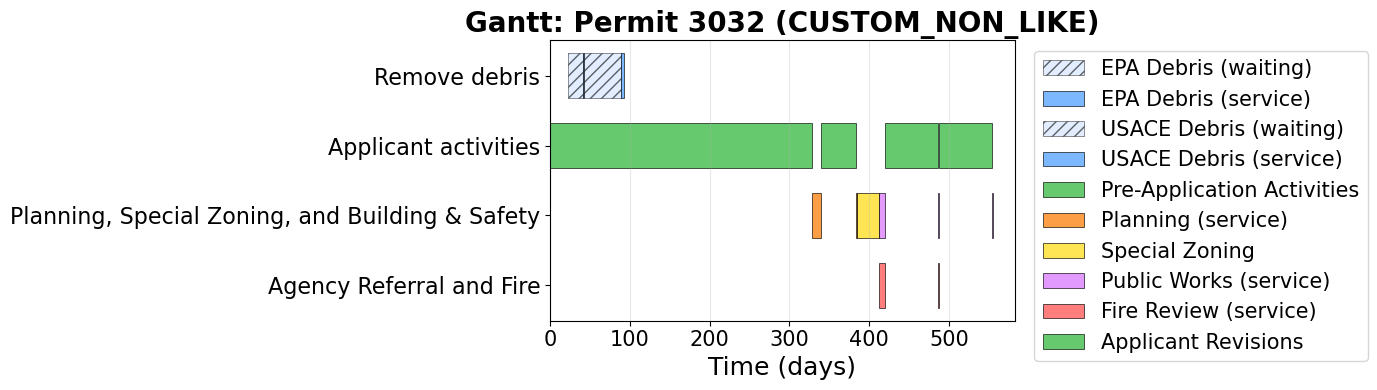

In [9]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    all_permits,
    segment_value=4,
    random_seed=100,
    figsize=(14, 4),
    color_option="option_1",
)
if fig:
    plt.show()

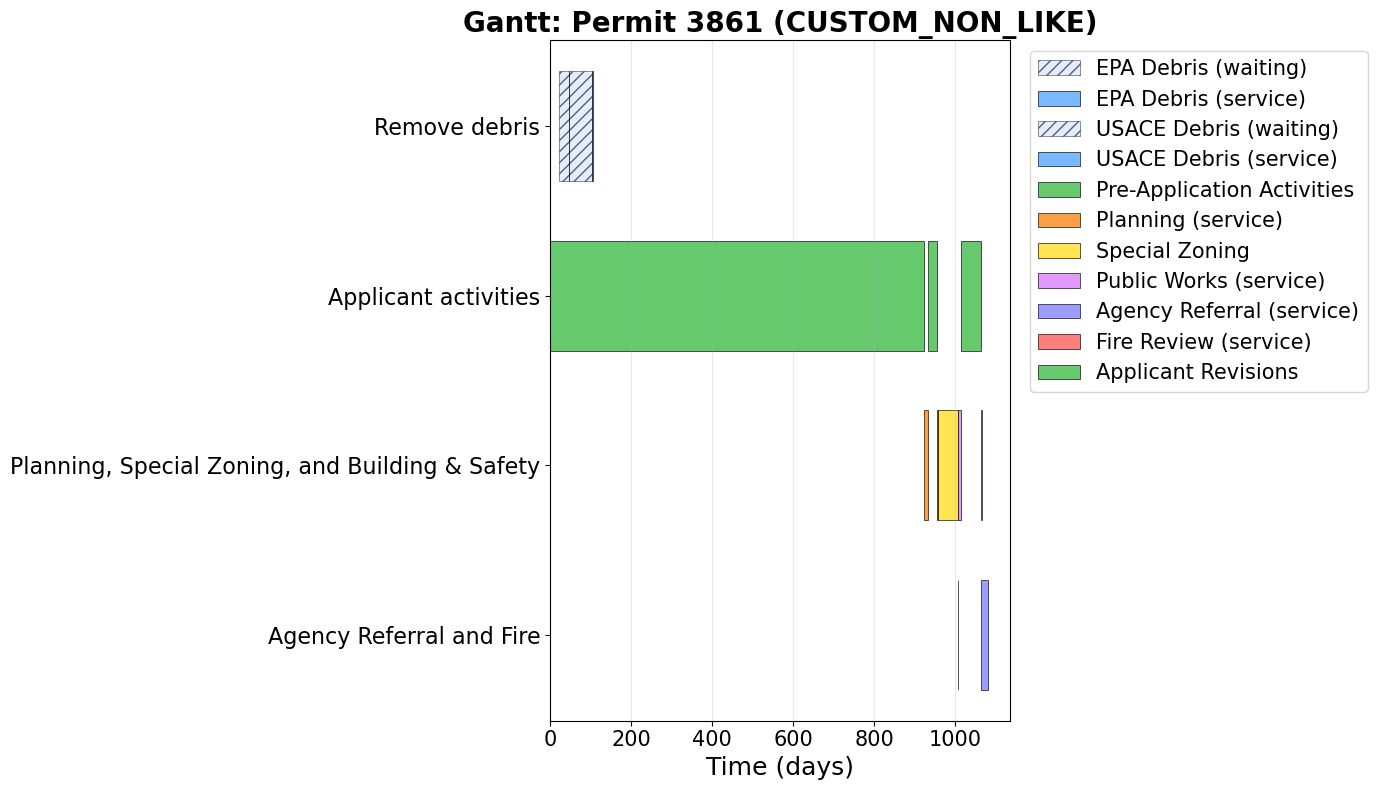

In [10]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt
import random

# One random run from the 100, same list index as before (representative Gantt)
_run = random.Random(42).choice(results)
_run_permits = _run.get("permits", [])

if not _run_permits:
    print("No permits available in selected run.")
else:
    selected_permit = random.Random(42).choice(_run_permits)
    fig, ax = plot_gantt_single_permit(
        selected_permit,
        figsize=(14, 8),
        color_option="option_1",
    )
    if fig:
        plt.show()

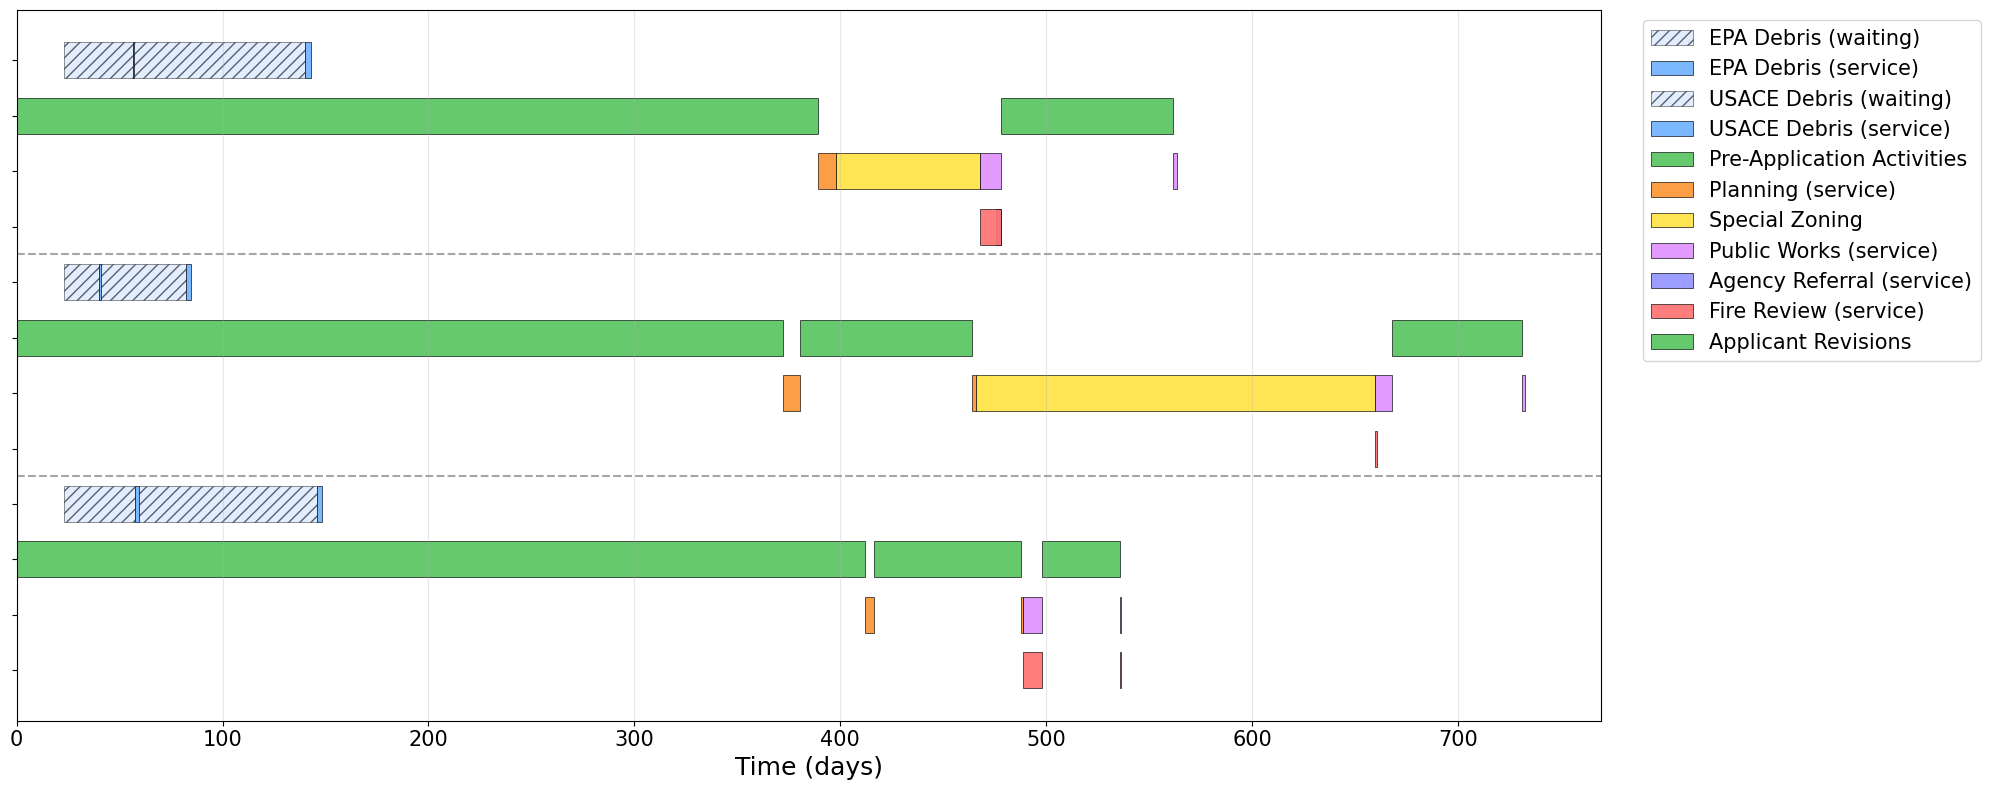

In [11]:
# Gantt chart for 3 random permits
from visualize_permits import plot_gantt_three_random_permits
import matplotlib.pyplot as plt

fig, ax = plot_gantt_three_random_permits(
    all_permits,
    random_seed=45,
    figsize=(20, 8),
    color_option="option_1",
)
if fig:
    plt.show()

Average waiting and service time by step (days):
  EPA Debris: waiting mean=19.99, σ=11.87; service mean=1.00, σ=0.49
  USACE Debris: waiting mean=49.28, σ=29.01; service mean=2.50, σ=0.50
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=651.01, σ=632.74
  Planning: waiting mean=0.00, σ=0.01; service mean=6.80, σ=1.85
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=57.55, σ=45.48
  Public Works: waiting mean=0.00, σ=0.00; service mean=8.33, σ=2.89
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=38.33, σ=30.05
  Fire Review: waiting mean=0.00, σ=0.01; service mean=3.74, σ=3.46
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=94.94, σ=40.23


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

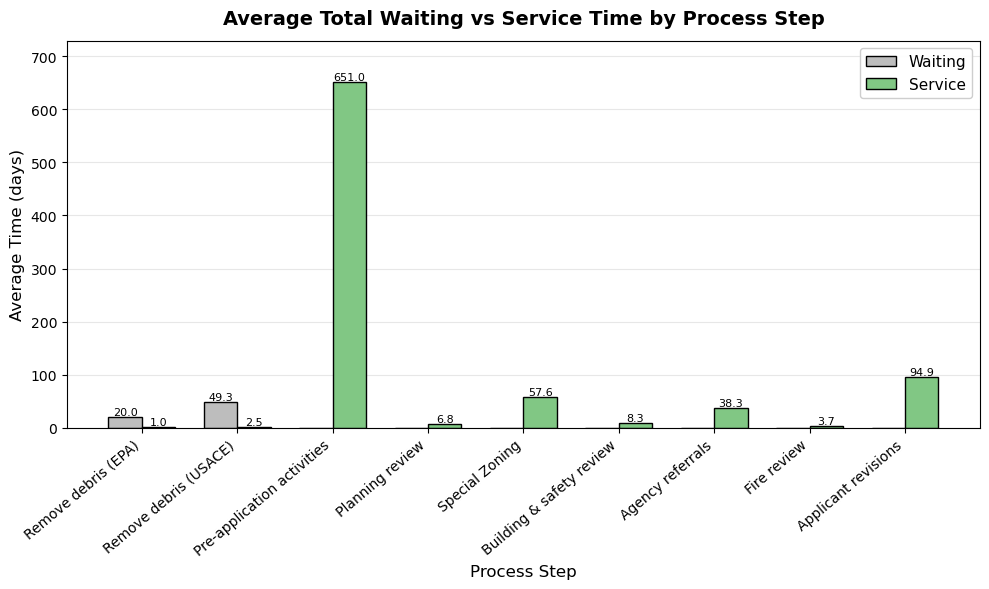

In [12]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step


# Visualize aggregate time spent in each process stage across all runs
label_map = {
    "EPA Debris": "Remove debris (EPA)",
    "USACE Debris": "Remove debris (USACE)",
    "Pre-Application Activities": "Pre-application activities",
    "Planning": "Planning review",
    "Special Zoning Review": "Special zoning review",
    "Public Works": "Building & safety review",
    "Agency Referral": "Agency referrals",
    "Fire Review": "Fire review",
    "Applicant Revisions": "Applicant revisions",
}
plot_average_waiting_and_service_by_step(all_permits, label_map=label_map)


Calculate statistics to understand the amount of time between the end of debris removal and plan submission

In [13]:
import statistics

deltas = [
    p.plan_prep_end - p.debris_removal_end
    for p in all_permits
    if p.plan_prep_end is not None and p.debris_removal_end is not None
]

statistics.mean(deltas), statistics.median(deltas)

(np.float64(555.2516773017517), np.float64(354.64215189725724))

In [14]:
starts = [p.epa_debris_service_start for p in all_permits if p.epa_debris_service_start is not None]
ends = [p.epa_debris_end for p in all_permits if p.epa_debris_end is not None]
if starts and ends:
    span = max(ends) - min(starts)  # first start → last end
    print("First EPA start:", min(starts), "Last EPA end:", max(ends), "Span:", span)

First EPA start: 23.0 Last EPA end: 65.91547866082273 Span: 42.91547866082273


In [15]:
# Deprecated plotting cell (kept for notebook history).
# Use the full-runtime utilization cell near the bottom (sim_full-based).

In [16]:
### Note

Staff utilization plots and day snapshots use the **multi-run output from the first cell** (`results`, `AVERAGE_STAFF_UTIL`).  
You do not need a separate “baseline” simulation cell anymore.

SyntaxError: invalid character '“' (U+201C) (2270592082.py, line 4)

In [ ]:
# Snapshot summaries for day 415 and 474 — mean / std across Monte Carlo runs
if "results" not in globals() or "NUM_PERMITS" not in globals():
    raise ValueError("Run the first cell first.")
if not COLLECT_PERMITS:
    raise ValueError("Set COLLECT_PERMITS=True in the first cell for snapshots.")

SNAPSHOT_DAYS = [415, 474]


def done_by_day(p, attr, day):
    t = getattr(p, attr)
    return (t is not None) and (t <= day)


def snapshot_counts(perms, day):
    issued = [p for p in perms if done_by_day(p, "planning_end", day)]
    ready = [p for p in perms if done_by_day(p, "ready_for_construction", day)]
    pw_done = [p for p in perms if done_by_day(p, "public_works_end", day)]
    fire_done = [p for p in perms if done_by_day(p, "fire_review_end", day)]

    issued_not_ready = [p for p in issued if not done_by_day(p, "ready_for_construction", day)]
    issued_pw_missing = [p for p in issued_not_ready if not done_by_day(p, "public_works_end", day)]
    issued_fire_missing = [p for p in issued_not_ready if not done_by_day(p, "fire_review_end", day)]
    issued_both_missing = [
        p
        for p in issued_not_ready
        if (not done_by_day(p, "public_works_end", day)) and (not done_by_day(p, "fire_review_end", day))
    ]
    issued_pw_done_fire_missing = [
        p
        for p in issued_not_ready
        if done_by_day(p, "public_works_end", day) and (not done_by_day(p, "fire_review_end", day))
    ]
    issued_fire_done_pw_missing = [
        p
        for p in issued_not_ready
        if done_by_day(p, "fire_review_end", day) and (not done_by_day(p, "public_works_end", day))
    ]
    return {
        "n_issued": len(issued),
        "n_ready": len(ready),
        "n_pw": len(pw_done),
        "n_fire": len(fire_done),
        "n_issued_not_ready": len(issued_not_ready),
        "n_pw_only_gap": len(issued_fire_done_pw_missing),
        "n_fire_only_gap": len(issued_pw_done_fire_missing),
        "n_both_gap": len(issued_both_missing),
        "n_missing_pw_any": len(issued_pw_missing),
        "n_missing_fire_any": len(issued_fire_missing),
    }


for day in SNAPSHOT_DAYS:
    rows = []
    for r in results:
        perms = r.get("permits") or []
        rows.append(snapshot_counts(perms, day))

    def mean_pct(key):
        vals = np.array([row[key] for row in rows], dtype=float) / NUM_PERMITS * 100.0
        return vals.mean(), vals.std(ddof=1) if len(vals) > 1 else 0.0

    print(f"Checkpoint day: {day} (mean ± std across {len(rows)} runs, % of {NUM_PERMITS} permits)")
    print("---")
    for label, key in [
        ("Permit issued (planning_end <= day)", "n_issued"),
        ("Public Works approved <= day", "n_pw"),
        ("Fire approved <= day", "n_fire"),
        ("Ready for construction <= day", "n_ready"),
    ]:
        m, s = mean_pct(key)
        print(f"{label:42s} {m:6.2f}% ± {s:5.2f}%")

    print("--- Issued but NOT ready (counts, mean ± std):")
    for label, key in [
        ("Total issued not ready", "n_issued_not_ready"),
        ("  Missing Public Works only", "n_pw_only_gap"),
        ("  Missing Fire only", "n_fire_only_gap"),
        ("  Missing BOTH PW and Fire", "n_both_gap"),
        ("  Missing PW (any)", "n_missing_pw_any"),
        ("  Missing Fire (any)", "n_missing_fire_any"),
    ]:
        vals = np.array([row[key] for row in rows], dtype=float)
        m, s = vals.mean(), vals.std(ddof=1) if len(vals) > 1 else 0.0
        print(f"{label:42s} {m:7.1f} ± {s:5.1f}")
    print()

Checkpoint day: 415
Total permits: 6571
---
Permit issued (planning_end <= day):      2640 ( 40.18%)
Public Works approved <= day:             2127 ( 32.37%)
Fire approved <= day:                     2263 ( 34.44%)
Ready for construction <= day:            2065 ( 31.43%)
---
Issued but NOT ready:                      575
  - Missing Public Works only:             177
  - Missing Fire only:                      41
  - Missing BOTH PW and Fire:              336
  - Missing PW (any):                      513
  - Missing Fire (any):                    377

Checkpoint day: 474
Total permits: 6571
---
Permit issued (planning_end <= day):      3080 ( 46.87%)
Public Works approved <= day:             2617 ( 39.83%)
Fire approved <= day:                     2729 ( 41.53%)
Ready for construction <= day:            2561 ( 38.97%)
---
Issued but NOT ready:                      519
  - Missing Public Works only:             152
  - Missing Fire only:                      40
  - Missing BOTH PW and 

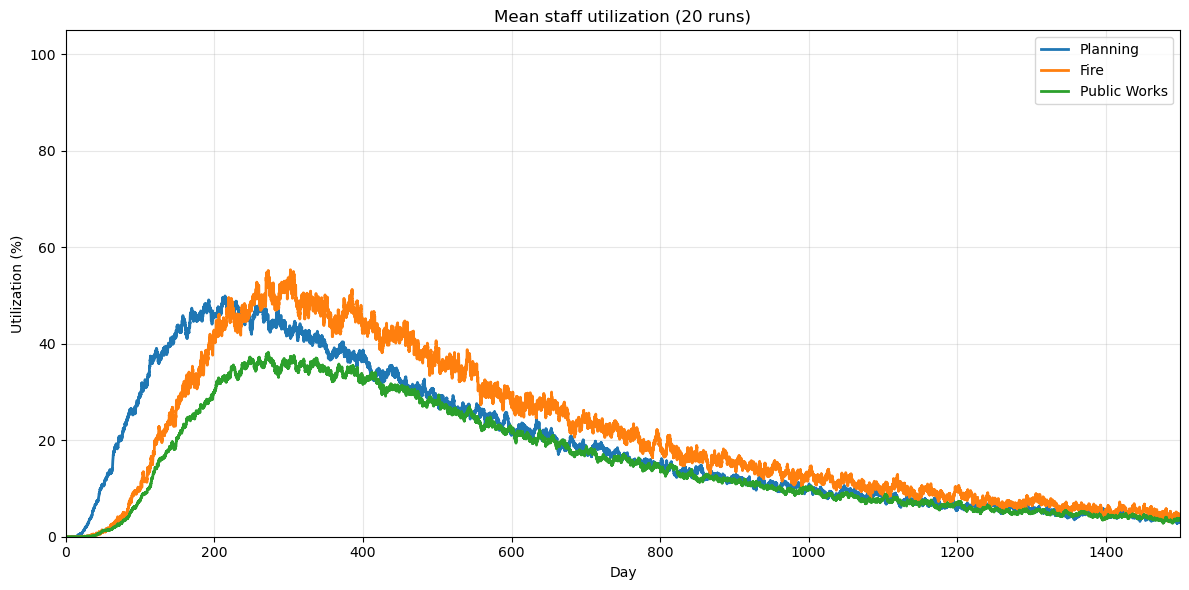

In [ ]:
# Mean staff utilization (multi-run average from the first cell)
from run_simulation import plot_staff_utilization_series

if "AVERAGE_STAFF_UTIL" not in globals():
    raise RuntimeError("Run the first cell so `AVERAGE_STAFF_UTIL` exists.")

plot_staff_utilization_series(
    AVERAGE_STAFF_UTIL,
    title=f"Mean Staff Utilization ({AVERAGE_STAFF_UTIL['n_runs']} runs)",
    xlim=(0, 1500),
    # ylim=(0, 100),
)


In [ ]:
# Peak mean utilization (same series as the plot above)
if "AVERAGE_STAFF_UTIL" not in globals():
    raise RuntimeError("Run the first cell so `AVERAGE_STAFF_UTIL` exists.")

u = AVERAGE_STAFF_UTIL
print("Planning peak mean (%):", 100 * max(u["planning"]))
print("Fire peak mean (%):", 100 * max(u["fire"]))
print("Public works peak mean (%):", 100 * max(u["public_works"]))
print("runs:", u["n_runs"], "max day:", u["max_day"])

Planning peak (%): 60.71428571428571
Fire peak (%): 75.71428571428571
Public works peak (%): 45.23809523809524
permits: 6571 end day: 15491.64963012077
